# Contrastive Retrieval Comparison

Notebook wrapper for the MLP vs atlas-free CNN contrastive text-to-brain and brain-to-text retrieval comparison. The evaluation code lives in `atlas_free_cnn.evaluation.compare_contrastive_retrieval`; this notebook only configures and calls it.

In [ ]:
from pathlib import Path
import sys

def find_repo_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "src" / "neurovlm").exists() and (candidate / "experiments" / "3dcnn" / "atlas_free_cnn").exists():
            return candidate
    raise RuntimeError("Could not find repo root. Start Jupyter from the neurovlm repo or update this cell.")

REPO_ROOT = find_repo_root()
THREEDCNN = REPO_ROOT / "experiments" / "3dcnn"
MODEL_COMPARISON_DIR = THREEDCNN / "model_comparison"
for path in [REPO_ROOT / "src", THREEDCNN, MODEL_COMPARISON_DIR]:
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

REPO_ROOT

PosixPath('/Users/borng/code/lab_work/neurovlm')

In [2]:
import pandas as pd

from atlas_free_cnn.evaluation.compare_contrastive_retrieval import (
    CONTRASTIVE_MODEL_IDS,
    CURVES_FILENAME,
    DATASETS,
    DEFAULT_OUTPUT_DIR,
    EXAMPLES_FILENAME,
    SUMMARY_FILENAME,
    run_comparison,
)

list(DATASETS), list(CONTRASTIVE_MODEL_IDS)

(['pubmed', 'nilearn', 'neurovault'],
 ['mlp_neurovlm',
  'cnn_contrastive_mixed',
  'cnn_contrastive_mixed_to_pubmed',
  'cnn_contrastive_mixed_to_nilearn',
  'cnn_contrastive_mixed_to_neurovault',
  'cnn_contrastive_mixed_pubmed',
  'cnn_contrastive_mixed_nilearn',
  'cnn_contrastive_mixed_neurovault',
  'cnn_contrastive_pubmed',
  'cnn_contrastive_nilearn',
  'cnn_contrastive_neurovault'])

## Configure

Set `RUN_MODE` below: `"quick"` is a fast sanity check (MLP on Nilearn only,
two samples -- still downloads the MLP autoencoder and a SPECTER2 text model
on first run, since Nilearn text is embedded on the fly, see
`load_mlp_nilearn_pairs`); `"full"` is the actual comparison across all
datasets/models (also downloads the CNN Stage 3 checkpoints, unified test
split, and normalized SPECTER2 cache). Everything below -- Run Comparison,
Inspect Outputs, Visualize Results -- uses whichever mode you pick here.

In [3]:
# RUN_MODE:
#   "quick" - fast sanity check: MLP only, Nilearn only, two samples.
#   "full"  - the actual comparison across all datasets/models.
RUN_MODE = "full"

if RUN_MODE == "quick":
    DATASETS_TO_RUN = ["nilearn"]
    MODELS = ["mlp_neurovlm"]
    LIMIT = 2
elif RUN_MODE == "full":
    DATASETS_TO_RUN = ["pubmed", "nilearn", "neurovault"]
    MODELS = [
        "mlp_neurovlm",
        "cnn_contrastive_mixed",
        "cnn_contrastive_pubmed",
        "cnn_contrastive_nilearn",
        "cnn_contrastive_neurovault",
    ]
    LIMIT = 32
else:
    raise ValueError(f"Unknown RUN_MODE {RUN_MODE!r}; expected 'quick' or 'full'")

DEVICE = "cpu"
BATCH_SIZE = 32

preferred_test_jsonl = REPO_ROOT / "experiments" / "3dcnn" / "atlas_free_cnn" / "cache" / "unified_jsonl" / "splits" / "test.jsonl"
TEST_JSONL = preferred_test_jsonl if preferred_test_jsonl.exists() else None

preferred_text_cache = REPO_ROOT / "experiments" / "3dcnn" / "atlas_free_cnn" / "cache" / "text_embeddings" / "specter2_stage3_stage4_emptycentered_unitnorm.pt"
TEXT_EMBEDDING_CACHE = preferred_text_cache if preferred_text_cache.exists() else None

OUTPUT_DIR = REPO_ROOT / DEFAULT_OUTPUT_DIR

{
    "run_mode": RUN_MODE,
    "datasets": DATASETS_TO_RUN,
    "models": MODELS,
    "limit": LIMIT,
    "device": DEVICE,
    "test_jsonl": str(TEST_JSONL) if TEST_JSONL else None,
    "text_embedding_cache": str(TEXT_EMBEDDING_CACHE) if TEXT_EMBEDDING_CACHE else None,
    "output_dir": str(OUTPUT_DIR),
}

{'run_mode': 'full',
 'datasets': ['pubmed', 'nilearn', 'neurovault'],
 'models': ['mlp_neurovlm',
  'cnn_contrastive_mixed',
  'cnn_contrastive_pubmed',
  'cnn_contrastive_nilearn',
  'cnn_contrastive_neurovault'],
 'limit': 32,
 'device': 'cpu',
 'test_jsonl': '/Users/borng/code/lab_work/neurovlm/experiments/3dcnn/atlas_free_cnn/cache/unified_jsonl/splits/test.jsonl',
 'text_embedding_cache': '/Users/borng/code/lab_work/neurovlm/experiments/3dcnn/atlas_free_cnn/cache/text_embeddings/specter2_stage3_stage4_emptycentered_unitnorm.pt',
 'output_dir': '/Users/borng/code/lab_work/neurovlm/experiments/3dcnn/atlas_free_cnn/outputs/model_comparison'}

## Run Comparison

In [4]:
result = run_comparison(
    datasets=DATASETS_TO_RUN,
    models=MODELS,
    limit=LIMIT,
    device=DEVICE,
    output_dir=OUTPUT_DIR,
    test_jsonl=TEST_JSONL,
    text_embedding_cache=TEXT_EMBEDDING_CACHE,
    batch_size=BATCH_SIZE,
)

result

PubMed split counts: {'train': 23894, 'val': 2987, 'test': 2987}


There are adapters available but none are activated for the forward pass.


{'summary_path': PosixPath('/Users/borng/code/lab_work/neurovlm/experiments/3dcnn/atlas_free_cnn/outputs/model_comparison/contrastive_retrieval_summary.csv'),
 'curves_path': PosixPath('/Users/borng/code/lab_work/neurovlm/experiments/3dcnn/atlas_free_cnn/outputs/model_comparison/contrastive_retrieval_curves.csv'),
 'examples_path': PosixPath('/Users/borng/code/lab_work/neurovlm/experiments/3dcnn/atlas_free_cnn/outputs/model_comparison/contrastive_retrieval_examples.csv'),
 'manifest_path': PosixPath('/Users/borng/code/lab_work/neurovlm/experiments/3dcnn/atlas_free_cnn/outputs/model_comparison/contrastive_retrieval_manifest.json'),
 'summary': [{'dataset': 'pubmed',
   'requested_model_id': 'mlp_neurovlm',
   'model_id': 'mlp_neurovlm',
   'model_family': 'mlp',
   'model_domain': None,
   'model_branch': None,
   'cnn_variant': '',
   'status': 'ok',
   'checkpoint_path': '',
   'checkpoint_error': '',
   'device': 'cpu',
   'limit': 32,
   'text_embedding_convention': 'normalized_spec

## Inspect Outputs

In [5]:
summary = pd.read_csv(result["summary_path"])
summary

,dataset,requested_model_id,model_id,model_family,model_domain,model_branch,cnn_variant,status,checkpoint_path,checkpoint_error,...,mean_random_recall@1,mean_recall@5,mean_random_recall@5,mean_recall@10,mean_random_recall@10,mean_recall@50,mean_random_recall@50,mean_auc,mean_paper_recall_curve_auc,mean_normalized_k_recall_curve_auc
0,pubmed,mlp_neurovlm,mlp_neurovlm,mlp,NaN,NaN,NaN,ok,NaN,NaN,...,0.03125,0.671875,0.15625,0.812500,0.3125,1.0,1.0,0.831055,0.831055,0.831055
1,pubmed,cnn_contrastive_mixed,cnn_contrastive_mixed_to_pubmed,cnn_contrastive,pubmed,baseline,mixed_to_pubmed,ok,/Users/borng/.cache/huggingface/hub/models--ne...,NaN,...,0.03125,0.546875,0.15625,0.781250,0.3125,1.0,1.0,0.807617,0.807617,0.807617
2,pubmed,cnn_contrastive_pubmed,cnn_contrastive_pubmed,cnn_contrastive,pubmed,specialized,pubmed,ok,/Users/borng/.cache/huggingface/hub/models--ne...,NaN,...,0.03125,0.531250,0.15625,0.812500,0.3125,1.0,1.0,0.804688,0.804688,0.804688
3,pubmed,cnn_contrastive_nilearn,cnn_contrastive_nilearn,cnn_contrastive,nilearn,specialized,nilearn,ok,/Users/borng/.cache/huggingface/hub/models--ne...,NaN,...,0.03125,0.265625,0.15625,0.500000,0.3125,1.0,1.0,0.619141,0.619141,0.619141
4,pubmed,cnn_contrastive_neurovault,cnn_contrastive_neurovault,cnn_contrastive,neurovault,specialized,neurovault,ok,/Users/borng/.cache/huggingface/hub/models--ne...,NaN,...,0.03125,0.312500,0.15625,0.437500,0.3125,1.0,1.0,0.607910,0.607910,0.607910
5,nilearn,mlp_neurovlm,mlp_neurovlm,mlp,NaN,NaN,NaN,ok,NaN,NaN,...,0.03125,0.406250,0.15625,0.640625,0.3125,1.0,1.0,0.710449,0.710449,0.710449
6,nilearn,cnn_contrastive_mixed,cnn_contrastive_mixed_to_nilearn,cnn_contrastive,nilearn,baseline,mixed_to_nilearn,ok,/Users/borng/.cache/huggingface/hub/models--ne...,NaN,...,0.03125,0.828125,0.15625,0.937500,0.3125,1.0,1.0,0.907227,0.907227,0.907227
7,nilearn,cnn_contrastive_pubmed,cnn_contrastive_pubmed,cnn_contrastive,pubmed,specialized,pubmed,ok,/Users/borng/.cache/huggingface/hub/models--ne...,NaN,...,0.03125,0.562500,0.15625,0.718750,0.3125,1.0,1.0,0.780273,0.780273,0.780273
8,nilearn,cnn_contrastive_nilearn,cnn_contrastive_nilearn,cnn_contrastive,nilearn,specialized,nilearn,ok,/Users/borng/.cache/huggingface/hub/models--ne...,NaN,...,0.03125,0.843750,0.15625,0.937500,0.3125,1.0,1.0,0.907227,0.907227,0.907227
9,nilearn,cnn_contrastive_neurovault,cnn_contrastive_neurovault,cnn_contrastive,neurovault,specialized,neurovault,ok,/Users/borng/.cache/huggingface/hub/models--ne...,NaN,...,0.03125,0.234375,0.15625,0.500000,0.3125,1.0,1.0,0.630859,0.630859,0.630859


In [6]:
metric_cols = [
    "dataset",
    "requested_model_id",
    "model_id",
    "status",
    "n_pairs",
    "normalized_k_recall_curve_auc",
    "t2i_normalized_k_recall_curve_auc",
    "i2t_normalized_k_recall_curve_auc",
    "mrr",
    "median_rank",
    "checkpoint_path",
    "skip_reason",
]
available = [col for col in metric_cols if col in summary.columns]
summary[available] if available else summary

,dataset,requested_model_id,model_id,status,n_pairs,normalized_k_recall_curve_auc,t2i_normalized_k_recall_curve_auc,i2t_normalized_k_recall_curve_auc,mrr,median_rank,checkpoint_path
0,pubmed,mlp_neurovlm,mlp_neurovlm,ok,32,0.831055,0.820312,0.841797,0.452627,3.0,NaN
1,pubmed,cnn_contrastive_mixed,cnn_contrastive_mixed_to_pubmed,ok,32,0.807617,0.811523,0.803711,0.365744,4.0,/Users/borng/.cache/huggingface/hub/models--ne...
2,pubmed,cnn_contrastive_pubmed,cnn_contrastive_pubmed,ok,32,0.804688,0.802734,0.806641,0.381512,4.0,/Users/borng/.cache/huggingface/hub/models--ne...
3,pubmed,cnn_contrastive_nilearn,cnn_contrastive_nilearn,ok,32,0.619141,0.619141,0.619141,0.215521,10.5,/Users/borng/.cache/huggingface/hub/models--ne...
4,pubmed,cnn_contrastive_neurovault,cnn_contrastive_neurovault,ok,32,0.607910,0.605469,0.610352,0.233049,11.0,/Users/borng/.cache/huggingface/hub/models--ne...
5,nilearn,mlp_neurovlm,mlp_neurovlm,ok,32,0.710449,0.736328,0.684570,0.324742,7.0,NaN
6,nilearn,cnn_contrastive_mixed,cnn_contrastive_mixed_to_nilearn,ok,32,0.907227,0.909180,0.905273,0.549574,2.0,/Users/borng/.cache/huggingface/hub/models--ne...
7,nilearn,cnn_contrastive_pubmed,cnn_contrastive_pubmed,ok,32,0.780273,0.779297,0.781250,0.375767,4.5,/Users/borng/.cache/huggingface/hub/models--ne...
8,nilearn,cnn_contrastive_nilearn,cnn_contrastive_nilearn,ok,32,0.907227,0.908203,0.906250,0.544114,2.0,/Users/borng/.cache/huggingface/hub/models--ne...
9,nilearn,cnn_contrastive_neurovault,cnn_contrastive_neurovault,ok,32,0.630859,0.638672,0.623047,0.177665,10.5,/Users/borng/.cache/huggingface/hub/models--ne...


## Visualize Results

Same fixed model-family colors as the other two comparison notebooks (MLP =
blue, CNN mixed baseline = green, CNN domain-specialized = the dataset's
color). The coverage table shows `status` per (dataset, model) so a missing
checkpoint is visible instead of silently absent from the bars below.
Bidirectional AUC is the mean of Text-to-Brain (T2B) and Brain-to-Text (B2T)
normalized Recall@K AUC; the two directions are also broken out separately
since a model can be much better at one than the other. MLP now runs on all
three datasets: PubMed and NeuroVault use precomputed main-package
resources, and Nilearn is bridged through the atlas-free CNN's packed
volumes (see `load_mlp_nilearn_pairs` / `mlp_masker_bridge`).


In [7]:
import matplotlib.pyplot as plt
import plotting_utils as pu

pu.coverage_table(summary)

dataset,neurovault,nilearn,pubmed
model_id,,,
cnn_contrastive_mixed_to_neurovault,ok,no_row,no_row
cnn_contrastive_mixed_to_nilearn,no_row,ok,no_row
cnn_contrastive_mixed_to_pubmed,no_row,no_row,ok
cnn_contrastive_neurovault,ok,ok,ok
cnn_contrastive_nilearn,ok,ok,ok
cnn_contrastive_pubmed,ok,ok,ok
mlp_neurovlm,ok,ok,ok


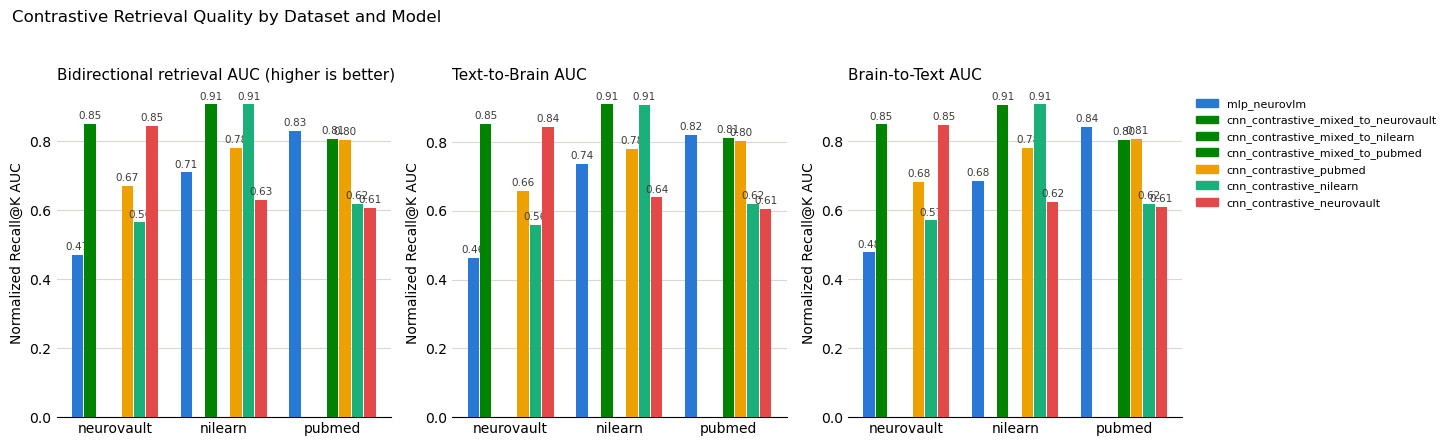

In [8]:
fig_auc, axes = plt.subplots(1, 3, figsize=(17, 4.5))
pu.grouped_bar(
    summary, category_col="dataset", series_col="model_id", value_col="normalized_k_recall_curve_auc",
    ax=axes[0], title="Bidirectional retrieval AUC (higher is better)", ylabel="Normalized Recall@K AUC", show_legend=False,
)
pu.grouped_bar(
    summary, category_col="dataset", series_col="model_id", value_col="t2i_normalized_k_recall_curve_auc",
    ax=axes[1], title="Text-to-Brain AUC", ylabel="Normalized Recall@K AUC", show_legend=False,
)
pu.grouped_bar(
    summary, category_col="dataset", series_col="model_id", value_col="i2t_normalized_k_recall_curve_auc",
    ax=axes[2], title="Brain-to-Text AUC", ylabel="Normalized Recall@K AUC",
)
fig_auc.suptitle("Contrastive Retrieval Quality by Dataset and Model", x=0.01, ha="left", fontsize=12)
fig_auc.tight_layout(rect=(0, 0, 0.86, 0.95))

In [9]:
curves_path = result["curves_path"]
curves = pd.read_csv(curves_path) if curves_path.exists() and curves_path.stat().st_size else pd.DataFrame()
curves.head(20)

,dataset,requested_model_id,model_id,model_family,model_domain,model_branch,cnn_variant,status,checkpoint_path,checkpoint_error,...,text_embedding_cache_path,split_strategy,comparison_space,n_pairs,k,normalized_k,t2i_recall,i2t_recall,mean_recall,random_recall
0,pubmed,mlp_neurovlm,mlp_neurovlm,mlp,NaN,NaN,NaN,ok,NaN,NaN,...,/Users/borng/code/lab_work/neurovlm/experiment...,main_pubmed_official_test_split,mlp_masker_flatmap,32,1,0.03125,0.21875,0.34375,0.281250,0.03125
1,pubmed,mlp_neurovlm,mlp_neurovlm,mlp,NaN,NaN,NaN,ok,NaN,NaN,...,/Users/borng/code/lab_work/neurovlm/experiment...,main_pubmed_official_test_split,mlp_masker_flatmap,32,2,0.06250,0.40625,0.43750,0.421875,0.06250
2,pubmed,mlp_neurovlm,mlp_neurovlm,mlp,NaN,NaN,NaN,ok,NaN,NaN,...,/Users/borng/code/lab_work/neurovlm/experiment...,main_pubmed_official_test_split,mlp_masker_flatmap,32,3,0.09375,0.53125,0.59375,0.562500,0.09375
3,pubmed,mlp_neurovlm,mlp_neurovlm,mlp,NaN,NaN,NaN,ok,NaN,NaN,...,/Users/borng/code/lab_work/neurovlm/experiment...,main_pubmed_official_test_split,mlp_masker_flatmap,32,4,0.12500,0.62500,0.65625,0.640625,0.12500
4,pubmed,mlp_neurovlm,mlp_neurovlm,mlp,NaN,NaN,NaN,ok,NaN,NaN,...,/Users/borng/code/lab_work/neurovlm/experiment...,main_pubmed_official_test_split,mlp_masker_flatmap,32,5,0.15625,0.65625,0.68750,0.671875,0.15625
5,pubmed,mlp_neurovlm,mlp_neurovlm,mlp,NaN,NaN,NaN,ok,NaN,NaN,...,/Users/borng/code/lab_work/neurovlm/experiment...,main_pubmed_official_test_split,mlp_masker_flatmap,32,6,0.18750,0.71875,0.71875,0.718750,0.18750
6,pubmed,mlp_neurovlm,mlp_neurovlm,mlp,NaN,NaN,NaN,ok,NaN,NaN,...,/Users/borng/code/lab_work/neurovlm/experiment...,main_pubmed_official_test_split,mlp_masker_flatmap,32,7,0.21875,0.71875,0.71875,0.718750,0.21875
7,pubmed,mlp_neurovlm,mlp_neurovlm,mlp,NaN,NaN,NaN,ok,NaN,NaN,...,/Users/borng/code/lab_work/neurovlm/experiment...,main_pubmed_official_test_split,mlp_masker_flatmap,32,8,0.25000,0.75000,0.78125,0.765625,0.25000
8,pubmed,mlp_neurovlm,mlp_neurovlm,mlp,NaN,NaN,NaN,ok,NaN,NaN,...,/Users/borng/code/lab_work/neurovlm/experiment...,main_pubmed_official_test_split,mlp_masker_flatmap,32,9,0.28125,0.75000,0.78125,0.765625,0.28125
9,pubmed,mlp_neurovlm,mlp_neurovlm,mlp,NaN,NaN,NaN,ok,NaN,NaN,...,/Users/borng/code/lab_work/neurovlm/experiment...,main_pubmed_official_test_split,mlp_masker_flatmap,32,10,0.31250,0.78125,0.84375,0.812500,0.31250


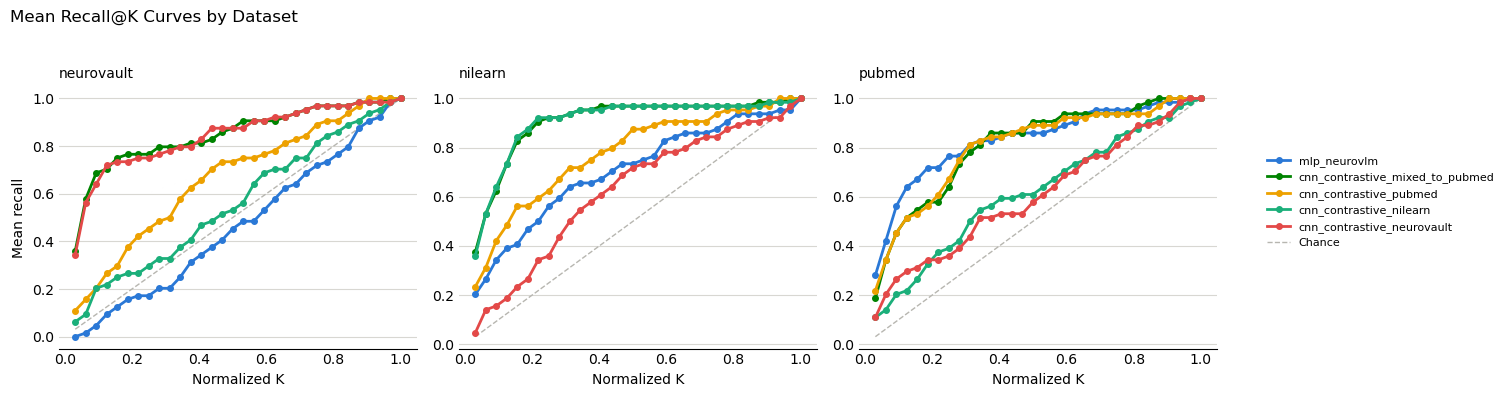

In [10]:
fig_recall_curves = pu.small_multiples_lines(
    curves, panel_col="dataset", x_col="normalized_k", y_col="mean_recall", series_col="model_id",
    suptitle="Mean Recall@K Curves by Dataset", xlabel="Normalized K", ylabel="Mean recall", reference_line=True,
)

In [11]:
examples_path = result["examples_path"]
examples = pd.read_csv(examples_path) if examples_path.exists() and examples_path.stat().st_size else pd.DataFrame()
examples.head(20)

,dataset,requested_model_id,model_id,model_family,model_domain,model_branch,cnn_variant,status,checkpoint_path,checkpoint_error,...,source,source_detail,tensor_index,t2i_rank,i2t_rank,t2i_top1_map_id,i2t_top1_text_id,matched_similarity,t2i_top1_similarity,i2t_top1_similarity
0,pubmed,mlp_neurovlm,mlp_neurovlm,mlp,NaN,NaN,NaN,ok,NaN,NaN,...,pubmed,main_pubmed_official_test_split,0,2,1,11430841,8994101,0.363912,0.375864,0.363912
1,pubmed,mlp_neurovlm,mlp_neurovlm,mlp,NaN,NaN,NaN,ok,NaN,NaN,...,pubmed,main_pubmed_official_test_split,1,5,3,11163375,10586971,0.197173,0.287206,0.242749
2,pubmed,mlp_neurovlm,mlp_neurovlm,mlp,NaN,NaN,NaN,ok,NaN,NaN,...,pubmed,main_pubmed_official_test_split,2,6,3,11230097,10634893,0.218348,0.331534,0.281139
3,pubmed,mlp_neurovlm,mlp_neurovlm,mlp,NaN,NaN,NaN,ok,NaN,NaN,...,pubmed,main_pubmed_official_test_split,3,1,1,10202567,10202567,0.323100,0.323100,0.323100
4,pubmed,mlp_neurovlm,mlp_neurovlm,mlp,NaN,NaN,NaN,ok,NaN,NaN,...,pubmed,main_pubmed_official_test_split,4,4,5,11595262,11239442,0.210917,0.254280,0.276998
5,pubmed,mlp_neurovlm,mlp_neurovlm,mlp,NaN,NaN,NaN,ok,NaN,NaN,...,pubmed,main_pubmed_official_test_split,5,2,2,10859136,9084599,0.273351,0.324290,0.313586
6,pubmed,mlp_neurovlm,mlp_neurovlm,mlp,NaN,NaN,NaN,ok,NaN,NaN,...,pubmed,main_pubmed_official_test_split,6,3,1,11430841,10426416,0.215936,0.321771,0.215936
7,pubmed,mlp_neurovlm,mlp_neurovlm,mlp,NaN,NaN,NaN,ok,NaN,NaN,...,pubmed,main_pubmed_official_test_split,7,1,1,10450889,10450889,0.433786,0.433786,0.433786
8,pubmed,mlp_neurovlm,mlp_neurovlm,mlp,NaN,NaN,NaN,ok,NaN,NaN,...,pubmed,main_pubmed_official_test_split,8,8,6,10450889,10859136,0.194121,0.281387,0.280316
9,pubmed,mlp_neurovlm,mlp_neurovlm,mlp,NaN,NaN,NaN,ok,NaN,NaN,...,pubmed,main_pubmed_official_test_split,9,3,2,11339984,10775540,0.280366,0.355325,0.323133


## Existing Output Loader

Use this cell when you have already run the CLI or a previous notebook cell and only want to inspect the saved CSVs.

In [12]:
saved_summary = OUTPUT_DIR / SUMMARY_FILENAME
saved_curves = OUTPUT_DIR / CURVES_FILENAME
saved_examples = OUTPUT_DIR / EXAMPLES_FILENAME

loaded_summary = pd.read_csv(saved_summary) if saved_summary.exists() and saved_summary.stat().st_size else pd.DataFrame()
loaded_curves = pd.read_csv(saved_curves) if saved_curves.exists() and saved_curves.stat().st_size else pd.DataFrame()
loaded_examples = pd.read_csv(saved_examples) if saved_examples.exists() and saved_examples.stat().st_size else pd.DataFrame()

loaded_summary.head(20)

,dataset,requested_model_id,model_id,model_family,model_domain,model_branch,cnn_variant,status,checkpoint_path,checkpoint_error,...,mean_random_recall@1,mean_recall@5,mean_random_recall@5,mean_recall@10,mean_random_recall@10,mean_recall@50,mean_random_recall@50,mean_auc,mean_paper_recall_curve_auc,mean_normalized_k_recall_curve_auc
0,pubmed,mlp_neurovlm,mlp_neurovlm,mlp,NaN,NaN,NaN,ok,NaN,NaN,...,0.03125,0.671875,0.15625,0.812500,0.3125,1.0,1.0,0.831055,0.831055,0.831055
1,pubmed,cnn_contrastive_mixed,cnn_contrastive_mixed_to_pubmed,cnn_contrastive,pubmed,baseline,mixed_to_pubmed,ok,/Users/borng/.cache/huggingface/hub/models--ne...,NaN,...,0.03125,0.546875,0.15625,0.781250,0.3125,1.0,1.0,0.807617,0.807617,0.807617
2,pubmed,cnn_contrastive_pubmed,cnn_contrastive_pubmed,cnn_contrastive,pubmed,specialized,pubmed,ok,/Users/borng/.cache/huggingface/hub/models--ne...,NaN,...,0.03125,0.531250,0.15625,0.812500,0.3125,1.0,1.0,0.804688,0.804688,0.804688
3,pubmed,cnn_contrastive_nilearn,cnn_contrastive_nilearn,cnn_contrastive,nilearn,specialized,nilearn,ok,/Users/borng/.cache/huggingface/hub/models--ne...,NaN,...,0.03125,0.265625,0.15625,0.500000,0.3125,1.0,1.0,0.619141,0.619141,0.619141
4,pubmed,cnn_contrastive_neurovault,cnn_contrastive_neurovault,cnn_contrastive,neurovault,specialized,neurovault,ok,/Users/borng/.cache/huggingface/hub/models--ne...,NaN,...,0.03125,0.312500,0.15625,0.437500,0.3125,1.0,1.0,0.607910,0.607910,0.607910
5,nilearn,mlp_neurovlm,mlp_neurovlm,mlp,NaN,NaN,NaN,ok,NaN,NaN,...,0.03125,0.406250,0.15625,0.640625,0.3125,1.0,1.0,0.710449,0.710449,0.710449
6,nilearn,cnn_contrastive_mixed,cnn_contrastive_mixed_to_nilearn,cnn_contrastive,nilearn,baseline,mixed_to_nilearn,ok,/Users/borng/.cache/huggingface/hub/models--ne...,NaN,...,0.03125,0.828125,0.15625,0.937500,0.3125,1.0,1.0,0.907227,0.907227,0.907227
7,nilearn,cnn_contrastive_pubmed,cnn_contrastive_pubmed,cnn_contrastive,pubmed,specialized,pubmed,ok,/Users/borng/.cache/huggingface/hub/models--ne...,NaN,...,0.03125,0.562500,0.15625,0.718750,0.3125,1.0,1.0,0.780273,0.780273,0.780273
8,nilearn,cnn_contrastive_nilearn,cnn_contrastive_nilearn,cnn_contrastive,nilearn,specialized,nilearn,ok,/Users/borng/.cache/huggingface/hub/models--ne...,NaN,...,0.03125,0.843750,0.15625,0.937500,0.3125,1.0,1.0,0.907227,0.907227,0.907227
9,nilearn,cnn_contrastive_neurovault,cnn_contrastive_neurovault,cnn_contrastive,neurovault,specialized,neurovault,ok,/Users/borng/.cache/huggingface/hub/models--ne...,NaN,...,0.03125,0.234375,0.15625,0.500000,0.3125,1.0,1.0,0.630859,0.630859,0.630859


## Export For Report

Save every figure and dataframe from this run into one directory (PNG +
CSV, plus a `manifest.json` listing them), so an HTML-report builder can
read a single, predictable location instead of re-running the comparison.

In [13]:
REPORT_ASSETS_DIR = OUTPUT_DIR / "report_assets" / "contrastive_retrieval"

report_manifest = pu.save_report_assets(
    REPORT_ASSETS_DIR,
    figures={"contrastive_retrieval_auc": fig_auc, "contrastive_retrieval_recall_curves": fig_recall_curves},
    dataframes={
        "contrastive_retrieval_summary": summary,
        "contrastive_retrieval_curves": curves,
        "contrastive_retrieval_examples": examples,
    },
)
report_manifest

{'figures': {'contrastive_retrieval_auc': '/Users/borng/code/lab_work/neurovlm/experiments/3dcnn/atlas_free_cnn/outputs/model_comparison/report_assets/contrastive_retrieval/contrastive_retrieval_auc.png',
  'contrastive_retrieval_recall_curves': '/Users/borng/code/lab_work/neurovlm/experiments/3dcnn/atlas_free_cnn/outputs/model_comparison/report_assets/contrastive_retrieval/contrastive_retrieval_recall_curves.png'},
 'dataframes': {'contrastive_retrieval_summary': '/Users/borng/code/lab_work/neurovlm/experiments/3dcnn/atlas_free_cnn/outputs/model_comparison/report_assets/contrastive_retrieval/contrastive_retrieval_summary.csv',
  'contrastive_retrieval_curves': '/Users/borng/code/lab_work/neurovlm/experiments/3dcnn/atlas_free_cnn/outputs/model_comparison/report_assets/contrastive_retrieval/contrastive_retrieval_curves.csv',
  'contrastive_retrieval_examples': '/Users/borng/code/lab_work/neurovlm/experiments/3dcnn/atlas_free_cnn/outputs/model_comparison/report_assets/contrastive_retriev